# Car price — Multiple Linear Regression that passes the assumption tests
All settings live in `config.py`. The previous version is in `backup/2026-10-06_before_mlr_assumptions/`.

Pipeline: load → clean (age filter, model names, unknown mileage) → split train/val/test → model groups + design matrix (learned from train only) →
**remedy ladder**: start from the old model and add one remedy at a time, re-running every assumption test → final model → evaluate **test** once.

Why each remedy is needed: `eda.ipynb` section 10.

In [1]:
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")   # with all 22 threads, OpenBLAS lstsq/pinv run ~25x slower on this machine
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from scipy.special import boxcox, inv_boxcox
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.stats.stattools import durbin_watson
import config as C

pd.set_option("display.width", 200, "display.max_columns", 50)
plt.rcParams["font.family"] = ["Tahoma", "DejaVu Sans"]   # Tahoma has Thai glyphs (รถราคาแพง)

## 1. Load + clean

In [2]:
df = pd.read_csv(C.DATA_PATH)
assert (df["year"] + df["car_age"]).nunique() == 1, "year/car_age no longer redundant"
n0 = len(df); df = df[df["car_age"] <= C.MAX_CAR_AGE]
print(f"removed {n0 - len(df)} rows with car_age > {C.MAX_CAR_AGE}")
df = df.drop(columns=C.DROP_COLS)
# model-name cleanup (no target used): compare names without spaces/hyphens, merge aliases, show most common spelling
df["model_raw"] = df["model"]
key = df["model"].str.upper().str.replace(r"[^A-Z0-9]", "", regex=True).replace(C.MODEL_ALIASES)
df["model"] = key.map(df.groupby(key)["model_raw"].agg(lambda s: s.value_counts().index[0]))
df["log_mileage"] = np.log(df["mileage"])
# unknown mileage (eda.ipynb 10.3): <= KM_UNKNOWN_MAX km on a car >= KM_UNKNOWN_MIN_AGE years old. Imputed in section 3 (train median km/year).
df["km_unknown"] = ((df["mileage"] <= C.KM_UNKNOWN_MAX) & (df["car_age"] >= C.KM_UNKNOWN_MIN_AGE)).astype(float)
print(df.shape, "| model names:", df["model_raw"].nunique(), "->", df["model"].nunique(), f"| unknown mileage: {int(df['km_unknown'].sum())} rows")

removed 287 rows with car_age > 25
(29817, 12) | model names: 495 -> 489 | unknown mileage: 1608 rows


## 2. Split train / validation / test (70/15/15, seed 99)
One random car of every (brand, model) goes to train first, so no model is train-unseen. The original row index is kept so the independence test can follow file order.

In [3]:
forced = df.groupby(["brand", "model"]).sample(n=1, random_state=C.SEED)
rest = df.drop(forced.index)
train_rest, temp = train_test_split(rest, train_size=round(C.TRAIN_SIZE * len(df)) - len(forced), random_state=C.SEED)
train = pd.concat([forced, train_rest])
val, test = train_test_split(temp, test_size=C.TEST_SIZE / (C.VAL_SIZE + C.TEST_SIZE), random_state=C.SEED)
print({k: len(v) for k, v in dict(train=train, val=val, test=test).items()})

{'train': 20872, 'val': 4472, 'test': 4473}


## 3. Model groups + design matrix (learned from train only)
`make_design(min_n, new)` builds X for train/val/test.
- **Model groups.** A model with ≥ `min_n` train rows keeps its own dummy. A rarer model goes to `รถราคาแพง` if its train median is ≥ `EXPENSIVE_MIN`, else to `OTHER_<BRAND>` if that bucket has ≥ `RARE_MIN` rows, else to `OTHER_<price tier>`. The old design used `min_n = RARE_MIN` (30); the new one uses `RARE_MIN_MODEL` (3), because pooled groups mix very different cars (eda 10.1).
- **Old features (`new=False`):** engine_capacity, log_mileage, car_age + dummies of model, fuel, gear, colour.
- **New features (`new=True`):**
  - log_mileage with unknown mileage imputed (train median km/year × age), plus a `km_unknown` flag
  - `age_c2` = (age − AGE_CENTRE)²
  - one age slope per brand, `slope_<BRAND>` = [brand] × (age − AGE_CENTRE), for brands with ≥ `SLOPE_BRAND_MIN` train rows; the rest share `slope_OTHER_BRANDS`. This replaces the single car_age slope (eda 10.2).
  - engine_capacity and the fuel dummies are centred within model (x − model mean in train). The model dummies already carry each model's typical engine and fuel, so the column space and the fit do not change, but VIF drops.

In [4]:
def model_grouper(min_n):
    mc = train["model"].value_counts(); keep_models = set(mc[mc >= min_n].index)
    mmed = train.groupby("model")[C.TARGET].median()
    expensive = set(mmed.index[mmed >= C.EXPENSIVE_MIN]) - keep_models   # rare AND expensive (median in train)
    rest = train.loc[~train["model"].isin(keep_models | expensive), "brand"].value_counts(); keep_brands = set(rest[rest >= C.RARE_MIN].index)
    tier = pd.cut(train.groupby("brand")[C.TARGET].median(), C.PRICE_TIERS, labels=C.TIER_LABELS).astype(str)
    default_tier = train["brand"].map(tier).mode()[0]   # for brands never seen in train
    def group(d):
        t = d["brand"].map(tier).fillna(default_tier)
        g = ("OTHER_" + d["brand"]).where(d["brand"].isin(keep_brands), "OTHER_" + t)
        g = g.where(~d["model"].isin(expensive), C.EXPENSIVE_LABEL)
        return d["model"].where(d["model"].isin(keep_models), g)
    return group

km_per_year = (train["mileage"] / train["car_age"].clip(lower=1))[train["mileage"] > C.KM_UNKNOWN_MAX].median()
slope_brands = train["brand"].value_counts().loc[lambda s: s >= C.SLOPE_BRAND_MIN].index.tolist()

def make_design(min_n, new=True):
    group = model_grouper(min_n)
    sets = [d.assign(model_clean=d["model"], model=group(d)) for d in (train, val, test)]
    tr = sets[0]
    levels = {"model": tr["model"].value_counts().index.tolist()}   # most frequent level first = reference (dropped)
    for c in [c for c in C.CAT_COLS if c != "model"]:
        counts = tr[c].value_counts(); levels[c] = counts[counts >= C.RARE_MIN].index.tolist()
        if c in C.RARE_LABEL and C.RARE_LABEL[c] not in levels[c]:
            levels[c].append(C.RARE_LABEL[c])
    def X_of(d):
        if new:
            a = d["car_age"] - C.AGE_CENTRE
            X = pd.DataFrame({"engine_capacity": d["engine_capacity"], "km_unknown": d["km_unknown"], "age_c2": a ** 2,
                              "log_mileage": np.where(d["km_unknown"] == 1, np.log(km_per_year * d["car_age"].clip(lower=1)), d["log_mileage"])}, index=d.index)
            for b in slope_brands:
                X[f"slope_{b}"] = (d["brand"] == b) * a
            X["slope_OTHER_BRANDS"] = (~d["brand"].isin(slope_brands)) * a
        else:
            X = d[["engine_capacity", "log_mileage", "car_age"]].copy()
        X = X.astype(float)
        for c in C.CAT_COLS:
            s = d[c].where(d[c].isin(levels[c]), C.RARE_LABEL.get(c))
            assert s.notna().all(), f"unseen level in {c} with no rare label"
            X = X.join(pd.get_dummies(pd.Categorical(s, categories=levels[c]), prefix=c, drop_first=True, dtype=float).set_index(d.index))
        return sm.add_constant(X, has_constant="add")
    Xs = [X_of(d) for d in sets]
    if new:
        for c in C.CENTRE_WITHIN_MODEL:
            mu = Xs[0][c].groupby(tr["model"]).mean()
            for d, X in zip(sets, Xs):
                X[c] -= d["model"].map(mu).values   # every val/test model is in train (forced split)
    return sets, Xs

(train_o, val_o, test_o), (Xo_tr, Xo_va, Xo_te) = make_design(C.RARE_MIN, new=False)
(train_n, val_n, test_n), (X_tr, X_va, X_te) = make_design(C.RARE_MIN_MODEL, new=True)
print(f"old design: {Xo_tr.shape[1]} columns, {train_o['model'].nunique()} model groups | "
      f"new design: {X_tr.shape[1]} columns, {train_n['model'].nunique()} model groups, {len(slope_brands)} + 1 brand age slopes")
print(f"imputed mileage for unknown rows: {km_per_year:,.0f} km/year x age")

old design: 144 columns, 123 model groups | new design: 359 columns, 319 model groups, 17 + 1 brand age slopes
imputed mileage for unknown rows: 14,688 km/year x age


## 4. Assumption tests
Same tests and pass rules as before.

| Assumption | Test | Pass rule |
|---|---|---|
| Independence | Durbin-Watson (residuals in file order) | DW in DW_RANGE |
| Homoscedasticity | Breusch-Pagan (on every column of X), White (special form: ŷ, ŷ²) | p > α |
| Normality | Kolmogorov-Smirnov, Lilliefors (all residuals); Shapiro-Wilk (see below) | p > α |
| Multicollinearity | VIF of every column of X (summarised per feature) | < VIF_MAX |

**Shapiro-Wilk and sample size.** scipy computes the Shapiro-Wilk p-value with Royston's approximation, which is only valid up to n = 5,000 (scipy warns above that). The train set has about 20,800 residuals, so Shapiro-Wilk runs on a random subsample of `SW_MAX_N` = 5,000 residuals (seed `SEED`). Section 6 also reports the test on all residuals, and how often it passes over 500 different subsamples.

The residual that is tested is the **internally studentized, whitened residual** r = e·√w / √(1 − h), where w is the WLS weight (w = 1 for OLS) and h the leverage.
With weights, the model assumes e·√w ~ N(0, σ²); dividing by √(1 − h) gives every row the same variance. Rows with h ≥ 0.99 are left out because their residual is 0 by construction.
VIF uses the unweighted X: VIF = diagonal of the inverse correlation matrix, which equals statsmodels `variance_inflation_factor` for a model with an intercept.

In [5]:
def row(cat, test, stat, p, rule, ok):
    return dict(assumption=cat, test=test, statistic=stat, p_value=p, rule=rule, passed=bool(ok))

def residual_tests(r, X, fit):
    """r: studentized whitened residual (Series, original row index), X: design used for the fit, fit: fitted values."""
    out = []
    dw = durbin_watson(r.sort_index().values)
    out.append(row("Independence", "Durbin-Watson", dw, np.nan, f"{C.DW_RANGE[0]}–{C.DW_RANGE[1]}", C.DW_RANGE[0] <= dw <= C.DW_RANGE[1]))
    Xv = X.values
    def r2_of(y, Z):
        b = np.linalg.lstsq(Z, y, rcond=None)[0]; u = y - Z @ b
        return 1 - u @ u / ((y - y.mean()) @ (y - y.mean()))
    lm = len(r) * r2_of(r.values ** 2, Xv); df_ = np.linalg.matrix_rank(Xv) - 1; p = stats.chi2.sf(lm, df_)   # = het_breuschpagan (Koenker)
    out.append(row("Homoscedasticity", "Breusch-Pagan", lm, p, "p > α", p > C.ALPHA))
    lm = len(r) * r2_of(r.values ** 2, sm.add_constant(np.column_stack([fit, fit ** 2]))); p = stats.chi2.sf(lm, 2)
    out.append(row("Homoscedasticity", "White (special form: ŷ, ŷ²)", lm, p, "p > α", p > C.ALPHA))
    d, p = stats.kstest((r - r.mean()) / r.std(ddof=0), "norm"); out.append(row("Normality", "Kolmogorov-Smirnov", d, p, "p > α", p > C.ALPHA))
    s = r.sample(min(len(r), C.SW_MAX_N), random_state=C.SEED)
    w, p = stats.shapiro(s.values); out.append(row("Normality", f"Shapiro-Wilk (random {len(s):,} residuals)", w, p, "p > α", p > C.ALPHA))
    d, p = lilliefors(r.values, dist="norm"); out.append(row("Normality", "Lilliefors", d, p, "p > α", p > C.ALPHA))
    return out

def vif_series(X):
    Z = X.drop(columns="const")
    return pd.Series(np.diag(np.linalg.pinv(np.corrcoef(Z.values, rowvar=False), hermitian=True)), index=Z.columns)

def vif_rows(X):
    v = vif_series(X); out = []
    for name, cols in {**{c: [c] for c in ["engine_capacity", "log_mileage", "car_age", "km_unknown", "age_c2"] if c in v},
                       **{f"{p} (max of dummies)": [c for c in v.index if c.startswith(p + "_")] for p in C.CAT_COLS},
                       "brand age slopes (max)": [c for c in v.index if c.startswith("slope_")]}.items():
        if cols:
            out.append(row("Multicollinearity", f"VIF {name}", v[cols].max(), np.nan, f"< {C.VIF_MAX} (max at {v[cols].idxmax()})", v[cols].max() < C.VIF_MAX))
    return out

## 5. Fitting: OLS, FGLS, outlier removal
- `fit`: (W)LS with statsmodels; leverage h = w·xᵀ(XᵀWX)⁻¹x.
- `fgls`: feasible GLS. Repeat `FGLS_ITERS` times: fit WLS → regress log(e²/(1 − h)) on a variance design → weights w = 1/σ̂². The variance design holds age, age², age³, ŷ, ŷ², every column of X and the brand dummies; dummy columns get a ridge penalty `VAR_RIDGE` so small groups borrow strength. With `VAR_CALIBRATE`, a last method-of-moments step rescales σ̂² so that the squared standardized residual has mean 1 given the same design (a ridge regression of r² on it).
- `fit_trimmed`: drop train rows with |studentized residual| > `OUTLIER_CUT`, refit, repeat until no row is beyond the cut (at most `OUTLIER_MAX_ROUNDS`).
- Target: Box-Cox with λ = `BOXCOX_LAMBDA` (0 = log). Predictions are back-transformed with the inverse Box-Cox (median prediction), as in the old notebook.

In [6]:
def fit(y, X, w=None):
    w = np.ones(len(y)) if w is None else w
    res = sm.WLS(y, X, weights=w).fit()
    h = w * ((X.values @ res.normalized_cov_params.values) * X.values).sum(1)
    return res, h, w

def variance_design(d, X, fitted):
    a = (d["car_age"] - C.AGE_CENTRE).values; f = fitted - fitted.mean()
    base = np.column_stack([np.ones(len(d)), a, a ** 2 / 10, a ** 3 / 100, f, f ** 2])
    Xv = X.drop(columns="const"); B = pd.get_dummies(d["brand"], dtype=float)
    Z = np.column_stack([base, Xv.values, B.values])
    penalty = C.VAR_RIDGE * np.r_[np.zeros(base.shape[1]), Xv.isin([0, 1]).all().values, np.ones(B.shape[1])]
    return Z, penalty

def ridge(Z, y, penalty):
    return np.linalg.solve(Z.T @ Z + np.diag(penalty), Z.T @ y)

def fgls(y, X, d, calibrate):
    w = np.ones(len(y))
    for _ in range(C.FGLS_ITERS):
        res, h, w = fit(y, X, w); ok = h < .99
        Z, pen = variance_design(d, X, res.fittedvalues.values)
        w = np.exp(-Z @ ridge(Z[ok], np.log(res.resid.values[ok] ** 2 / (1 - h[ok])), pen))
    if calibrate:   # method of moments: E[r^2 | Z] = 1
        res, h, w = fit(y, X, w); ok = h < .99
        Z, pen = variance_design(d, X, res.fittedvalues.values)
        r2 = res.resid.values ** 2 * w / (1 - h)
        w = w / np.clip(Z @ ridge(Z[ok], r2[ok], pen), 0.25, 4)
    return fit(y, X, w)

def studentized(res, h, w):
    return pd.Series(res.resid.values * np.sqrt(w) / np.sqrt(np.clip(1 - h, 1e-12, None)), index=res.resid.index)

def fit_trimmed(d, X, weighted=True, calibrate=False, cut=None, lam=0.0):
    keep, dropped = d.index, []
    for k in range(C.OUTLIER_MAX_ROUNDS + 1):
        y = pd.Series(boxcox(d.loc[keep, C.TARGET].values, lam), index=keep)
        res, h, w = fgls(y, X.loc[keep], d.loc[keep], calibrate) if weighted else fit(y, X.loc[keep])
        r = studentized(res, h, w); ok = h < .99
        out = ((r / r[ok].std()).abs() > cut) & ok if cut is not None else pd.Series(False, index=keep)
        if not out.any() or k == C.OUTLIER_MAX_ROUNDS:
            break
        dropped += list(keep[out.values]); keep = keep[~out.values]
    return dict(res=res, h=h, w=w, r=r[ok], X=X.loc[keep][ok], fit=res.fittedvalues.values[ok], keep=keep, dropped=dropped, lam=lam)

def predict(m, X):
    return inv_boxcox(X.values @ m["res"].params.values, m["lam"])

## 6. Remedy ladder
Each step adds one remedy to the previous one and re-runs every test. Step 0 is the old notebook's best model (OLS, Box-Cox λ fitted on train y, `RARE_MIN` model groups).
Validation MAE / R² are on the price scale.

In [7]:
lam_old = stats.boxcox(train_o[C.TARGET].values)[1]
steps = [  # name, design, weighted, calibrate, outlier cut, Box-Cox lambda
    ("0. old model (OLS, Box-Cox, model groups >= 30 rows)", "old", False, False, None, lam_old),
    ("1. log target, own dummy for models >= 3 rows",        "fine", False, False, None, 0.0),
    ("2. + unknown mileage, age^2, brand age slopes, centring", "new", False, False, None, 0.0),
    ("3. + FGLS (WLS with estimated variance)",              "new", True, False, None, 0.0),
    (f"4. + drop train rows with |r| > {C.OUTLIER_CUT}",     "new", True, False, C.OUTLIER_CUT, 0.0),
    ("5. + variance calibration (method of moments)",        "new", True, True, C.OUTLIER_CUT, 0.0),
    (f"6. + Box-Cox lambda = {C.BOXCOX_LAMBDA} (final)",     "new", True, True, C.OUTLIER_CUT, C.BOXCOX_LAMBDA),
]
(train_f, val_f, _), (X1_tr, X1_va, _) = make_design(C.RARE_MIN_MODEL, new=False)   # step 1: old features, finer model groups
designs = {"old": (train_o, val_o, Xo_tr, Xo_va), "fine": (train_f, val_f, X1_tr, X1_va), "new": (train_n, val_n, X_tr, X_va)}
results, scores, fits = [], [], {}
for name, design, weighted, calibrate, cut, lam in steps:
    tr, va, Xt, Xv = designs[design]
    m = fit_trimmed(tr, Xt, weighted, calibrate, cut, lam)
    fits[name] = m
    results += [dict(step=name, **x) for x in residual_tests(m["r"], m["X"], m["fit"]) + vif_rows(Xt)]
    p = predict(m, Xv)
    scores.append(dict(step=name, n_train=len(m["keep"]), n_cols=Xt.shape[1], val_MAE=mean_absolute_error(va[C.TARGET], p),
                       val_R2=r2_score(va[C.TARGET], p), resid_skew=stats.skew(m["r"]), resid_excess_kurtosis=stats.kurtosis(m["r"])))
    print(f"{name}: done")
results = pd.DataFrame(results)
scores = pd.DataFrame(scores).set_index("step")
scores["passed"] = results.groupby("step", sort=False)["passed"].sum()
scores["total"] = results.groupby("step", sort=False)["passed"].size()
scores.round(3)

0. old model (OLS, Box-Cox, model groups >= 30 rows): done


1. log target, own dummy for models >= 3 rows: done


2. + unknown mileage, age^2, brand age slopes, centring: done


3. + FGLS (WLS with estimated variance): done


4. + drop train rows with |r| > 3.5: done


5. + variance calibration (method of moments): done


6. + Box-Cox lambda = 0.08 (final): done


,n_train,n_cols,val_MAE,val_R2,resid_skew,resid_excess_kurtosis,passed,total
step,,,,,,,,
"0. old model (OLS, Box-Cox, model groups >= 30 rows)",20872,144,108813.919,0.792,0.144,7.699,8,13
"1. log target, own dummy for models >= 3 rows",20872,340,92386.396,0.868,0.064,5.489,7,13
"2. + unknown mileage, age^2, brand age slopes, centring",20872,359,87055.754,0.877,0.055,6.360,10,15
3. + FGLS (WLS with estimated variance),20872,359,85684.661,0.870,-0.080,1.243,10,15
4. + drop train rows with |r| > 3.5,20787,359,85707.980,0.869,-0.050,0.102,15,15
5. + variance calibration (method of moments),20812,359,85499.034,0.870,-0.036,0.041,15,15
6. + Box-Cox lambda = 0.08 (final),20812,359,86429.926,0.866,-0.001,0.028,15,15


### Pass/fail matrix

In [8]:
pd.set_option("display.max_rows", 200, "display.max_colwidth", 60)
rows_in_order = pd.MultiIndex.from_frame(results[["assumption", "test"]].drop_duplicates())   # steps have different VIF rows
matrix = results.pivot_table(index=["assumption", "test"], columns="step", values="passed", aggfunc="first").reindex(rows_in_order)[[s[0] for s in steps]]
matrix.columns = [c.split(".")[0] for c in matrix.columns]   # step number
matrix.astype(object).replace({True: "PASS", False: "FAIL"}).fillna("–")   # – = feature not in that step's design

0     1     2     3     4     5     6
assumption        test                                                                           
Independence      Durbin-Watson                          PASS  PASS  PASS  PASS  PASS  PASS  PASS
Homoscedasticity  Breusch-Pagan                          FAIL  FAIL  FAIL  FAIL  PASS  PASS  PASS
                  White (special form: ŷ, ŷ²)            FAIL  FAIL  FAIL  FAIL  PASS  PASS  PASS
Normality         Kolmogorov-Smirnov                     FAIL  FAIL  FAIL  FAIL  PASS  PASS  PASS
                  Shapiro-Wilk (random 5,000 residuals)  FAIL  FAIL  FAIL  FAIL  PASS  PASS  PASS
                  Lilliefors                             FAIL  FAIL  FAIL  FAIL  PASS  PASS  PASS
Multicollinearity VIF engine_capacity                    PASS  PASS  PASS  PASS  PASS  PASS  PASS
                  VIF log_mileage                        PASS  PASS  PASS  PASS  PASS  PASS  PASS
                  VIF car_age                            PASS  PASS     –     –     –     –     –
                  VIF model (max of dummies)             PASS  PASS  PASS  PASS  PASS  PASS  PASS
                  VIF fuel_type (max of dummies)         PASS  FAIL  PASS  PASS  PASS  PASS  PASS
                  VIF gear_type (max of dummies)         PASS  PASS  PASS  PASS  PASS  PASS  PASS
                  VIF color (max of dummies)             PASS  PASS  PASS  PASS  PASS  PASS  PASS
                  VIF km_unknown                            –     –  PASS  PASS  PASS  PASS  PASS
                  VIF age_c2                                –     –  PASS  PASS  PASS  PASS  PASS
                  VIF brand age slopes (max)                –     –  PASS  PASS  PASS  PASS  PASS

### Detail of the final model (statistics and p-values)

In [9]:
final_name = steps[-1][0]
final = fits[final_name]
results.query("step == @final_name").drop(columns="step").round(4)

,assumption,test,statistic,p_value,rule,passed
86,Independence,Durbin-Watson,1.7113,NaN,1.5–2.5,True
87,Homoscedasticity,Breusch-Pagan,119.9814,1.0000,p > α,True
88,Homoscedasticity,"White (special form: ŷ, ŷ²)",0.8702,0.6472,p > α,True
89,Normality,Kolmogorov-Smirnov,0.0048,0.7329,p > α,True
90,Normality,"Shapiro-Wilk (random 5,000 residuals)",0.9996,0.3164,p > α,True
91,Normality,Lilliefors,0.0048,0.2752,p > α,True
92,Multicollinearity,VIF engine_capacity,1.1394,NaN,< 7.0 (max at engine_capacity),True
93,Multicollinearity,VIF log_mileage,1.8579,NaN,< 7.0 (max at log_mileage),True
94,Multicollinearity,VIF km_unknown,1.0365,NaN,< 7.0 (max at km_unknown),True
95,Multicollinearity,VIF age_c2,3.2650,NaN,< 7.0 (max at age_c2),True


### Shapiro-Wilk on all residuals vs subsamples (final model)
On all ~20,800 residuals, Shapiro-Wilk can detect a tiny departure from normality (eda 10.6: at this n it rejects most t-distributions with 50 d.f.).
W close to 1 means the residuals are very close to normal. The pass rate over 500 random subsamples shows that the subsample result in the matrix does not depend on one lucky seed.

In [10]:
import warnings
r = final["r"]
with warnings.catch_warnings():
    warnings.simplefilter("ignore")   # scipy: p-value may be inaccurate for N > 5000
    w_all, p_all = stats.shapiro(r.values)
rng = np.random.default_rng(C.SEED)
p_sub = np.array([stats.shapiro(rng.choice(r.values, C.SW_MAX_N, replace=False)).pvalue for _ in range(500)])
print(f"all {len(r):,} residuals: W = {w_all:.5f}, p = {p_all:.4f}  (p-value outside the valid range n <= 5,000)")
print(f"500 random subsamples of {C.SW_MAX_N:,}: pass rate {np.mean(p_sub > C.ALPHA):.0%}, median p = {np.median(p_sub):.3f}")

all 20,812 residuals: W = 0.99977, p = 0.0179  (p-value outside the valid range n <= 5,000)
500 random subsamples of 5,000: pass rate 91%, median p = 0.280


### Box-Cox λ: residual skewness and kurtosis (final rows and settings, λ varied)
λ = `BOXCOX_LAMBDA` is the value where the residual skewness is ≈ 0, i.e. the transformation to symmetry (Hinkley 1975, *Biometrika* 62:101–111).
The profile likelihood of the weighted model prefers λ < 0 instead; it is not used because the variance model, not λ, takes care of the changing spread here.

In [11]:
rows = []
keep = final["keep"]
for lam in [0.0, 0.04, 0.08, 0.12, 0.16]:
    y = pd.Series(boxcox(train_n.loc[keep, C.TARGET].values, lam), index=keep)
    res_l, h_l, w_l = fgls(y, X_tr.loc[keep], train_n.loc[keep], calibrate=True)
    r_l = studentized(res_l, h_l, w_l)[h_l < .99]
    rows.append(dict(boxcox_lambda=lam, skewness=stats.skew(r_l), excess_kurtosis=stats.kurtosis(r_l)))
pd.DataFrame(rows).set_index("boxcox_lambda").round(4)

,skewness,excess_kurtosis
boxcox_lambda,,
0.00,-0.0450,0.0627
0.04,-0.0211,0.0413
0.08,-0.0007,0.0276
0.12,0.0258,0.0291
0.16,0.0524,0.0351


## 7. Residual diagnostics: old model vs final model

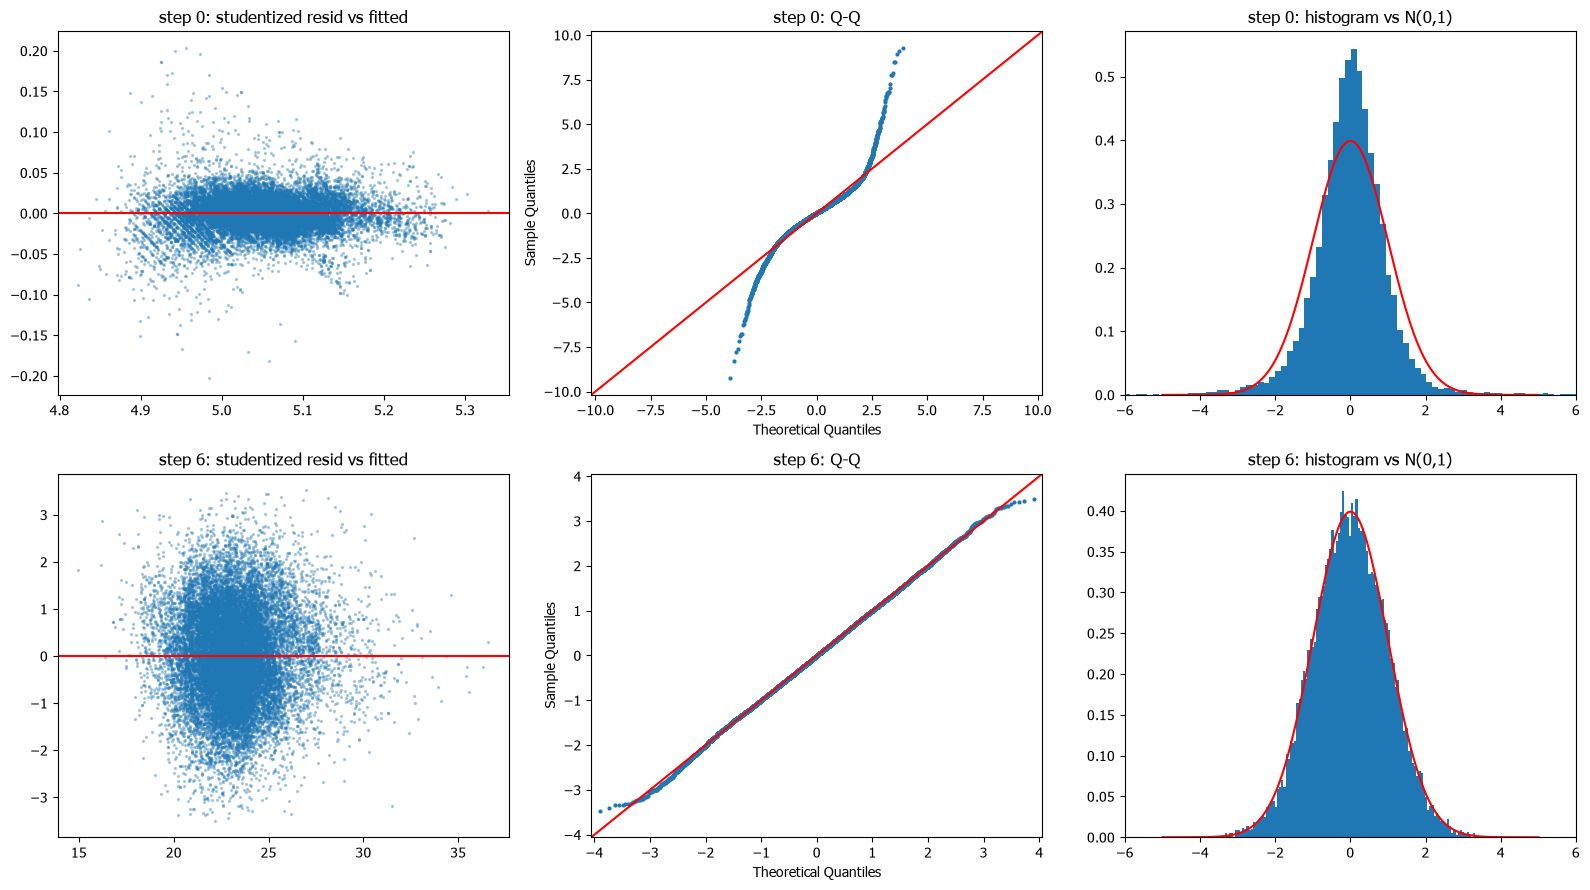

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(16, 9))
for i, name in enumerate([steps[0][0], final_name]):
    m = fits[name]; r = m["r"]
    ax[i, 0].scatter(m["fit"], r, s=2, alpha=.3); ax[i, 0].axhline(0, c="r"); ax[i, 0].set_title(f"step {name[0]}: studentized resid vs fitted")
    sm.qqplot(r, line="45", fit=True, ax=ax[i, 1], markersize=2); ax[i, 1].set_title(f"step {name[0]}: Q-Q")
    ax[i, 2].hist((r - r.mean()) / r.std(), bins=120, density=True); xs = np.linspace(-5, 5, 300); ax[i, 2].plot(xs, stats.norm.pdf(xs), c="r")
    ax[i, 2].set_xlim(-6, 6); ax[i, 2].set_title(f"step {name[0]}: histogram vs N(0,1)")
plt.tight_layout(); plt.show()

## 8. Rows removed as outliers (train only)
These rows are removed from the fit only. Validation and test keep every row.

In [13]:
raw = pd.read_csv(C.DATA_PATH)
drop = raw.loc[final["dropped"]].assign(model_group=train_n.loc[final["dropped"], "model"])
print(f"{len(drop)} of {len(train_n)} train rows removed ({100 * len(drop) / len(train_n):.2f}%)")
drop.sort_values("price", ascending=False).head(40)

60 of 20872 train rows removed (0.29%)


,brand,model,car_type,fuel_type,gear_type,color,engine_capacity,mileage,year,car_age,price,model_group
23048,PORSCHE,CAYENNE,SUV,Benzine,Automatic,White,4000,57500,2022,4,10590000,CAYENNE
16648,PORSCHE,CAYENNE,SUV,Benzine,Automatic,Silver Bronze,4000,17500,2021,5,8900000,CAYENNE
19655,PORSCHE,CAYENNE,SUV,Benzine,Automatic,Black,4000,25777,2023,3,8900000,CAYENNE
23910,PORSCHE,CAYENNE,SUV,Hybrid,Automatic,Black,3000,18000,2020,6,7290000,CAYENNE
27392,PORSCHE,PANAMERA,Sedan,Hybrid,Automatic,White,3000,2500,2013,13,4250000,PANAMERA
17072,VOLVO,XC60,SUV,Hybrid,Automatic,White,2000,7500,2025,1,3690000,XC60
19657,MERCEDES-BENZ,S500,Sedan,Benzine,Automatic,White,3000,71296,2022,4,3590000,S500
4432,TOYOTA,COROLLA,Sedan,Benzine,Manual,White,1600,3000,2023,3,3090000,COROLLA
23799,MINI,COUNTRYMAN,Hatchback,Benzine,Automatic,White,2000,2500,2021,5,3050000,COUNTRYMAN
25467,BMW,X3,SUV,Diesel,Automatic,White,2000,62500,2020,6,2799000,X3


## 9. Does each feature matter? Joint F-test per feature (final model, H0: all its coefficients = 0)

In [14]:
res = final["res"]
ft = []
for name, cols in {**{c: [c] for c in ["engine_capacity", "log_mileage", "km_unknown", "age_c2"]},
                   "brand age slopes": [c for c in X_tr.columns if c.startswith("slope_")],
                   **{c: [k for k in X_tr.columns if k.startswith(c + "_")] for c in C.CAT_COLS}}.items():
    R = np.zeros((len(cols), len(res.params))); R[range(len(cols)), [res.params.index.get_loc(k) for k in cols]] = 1
    t = res.f_test(R)
    ft.append(dict(feature=name, df=len(cols), F=float(np.squeeze(t.fvalue)), p_value=float(t.pvalue), significant=t.pvalue < C.ALPHA))
pd.DataFrame(ft).set_index("feature").round(4)

,df,F,p_value,significant
feature,,,,
engine_capacity,1,232.6350,0.0000,True
log_mileage,1,1675.2175,0.0000,True
km_unknown,1,0.0429,0.8358,False
age_c2,1,506.2536,0.0000,True
brand age slopes,18,1490.8812,0.0000,True
model,318,882.0963,0.0000,True
fuel_type,2,249.2180,0.0000,True
gear_type,1,908.1164,0.0000,True
color,15,12.2860,0.0000,True


## 10. Evaluate test once (old model vs final model)

In [15]:
rows = []
for name, Xs, sets in [(steps[0][0], Xo_te, test_o), (final_name, X_te, test_n)]:
    p = predict(fits[name], Xs); y = sets[C.TARGET]
    rows.append(dict(model=name, test_RMSE=mean_squared_error(y, p) ** 0.5, test_MAE=mean_absolute_error(y, p),
                     test_MAPE=np.mean(np.abs(p - y) / y), test_R2=r2_score(y, p)))
pd.DataFrame(rows).set_index("model").round(4)

,test_RMSE,test_MAE,test_MAPE,test_R2
model,,,,
"0. old model (OLS, Box-Cox, model groups >= 30 rows)",262703.3887,103883.1799,0.1558,0.8226
6. + Box-Cox lambda = 0.08 (final),192231.7543,85432.3622,0.1380,0.9050


## 11. Actual vs predicted (final model, price scale)

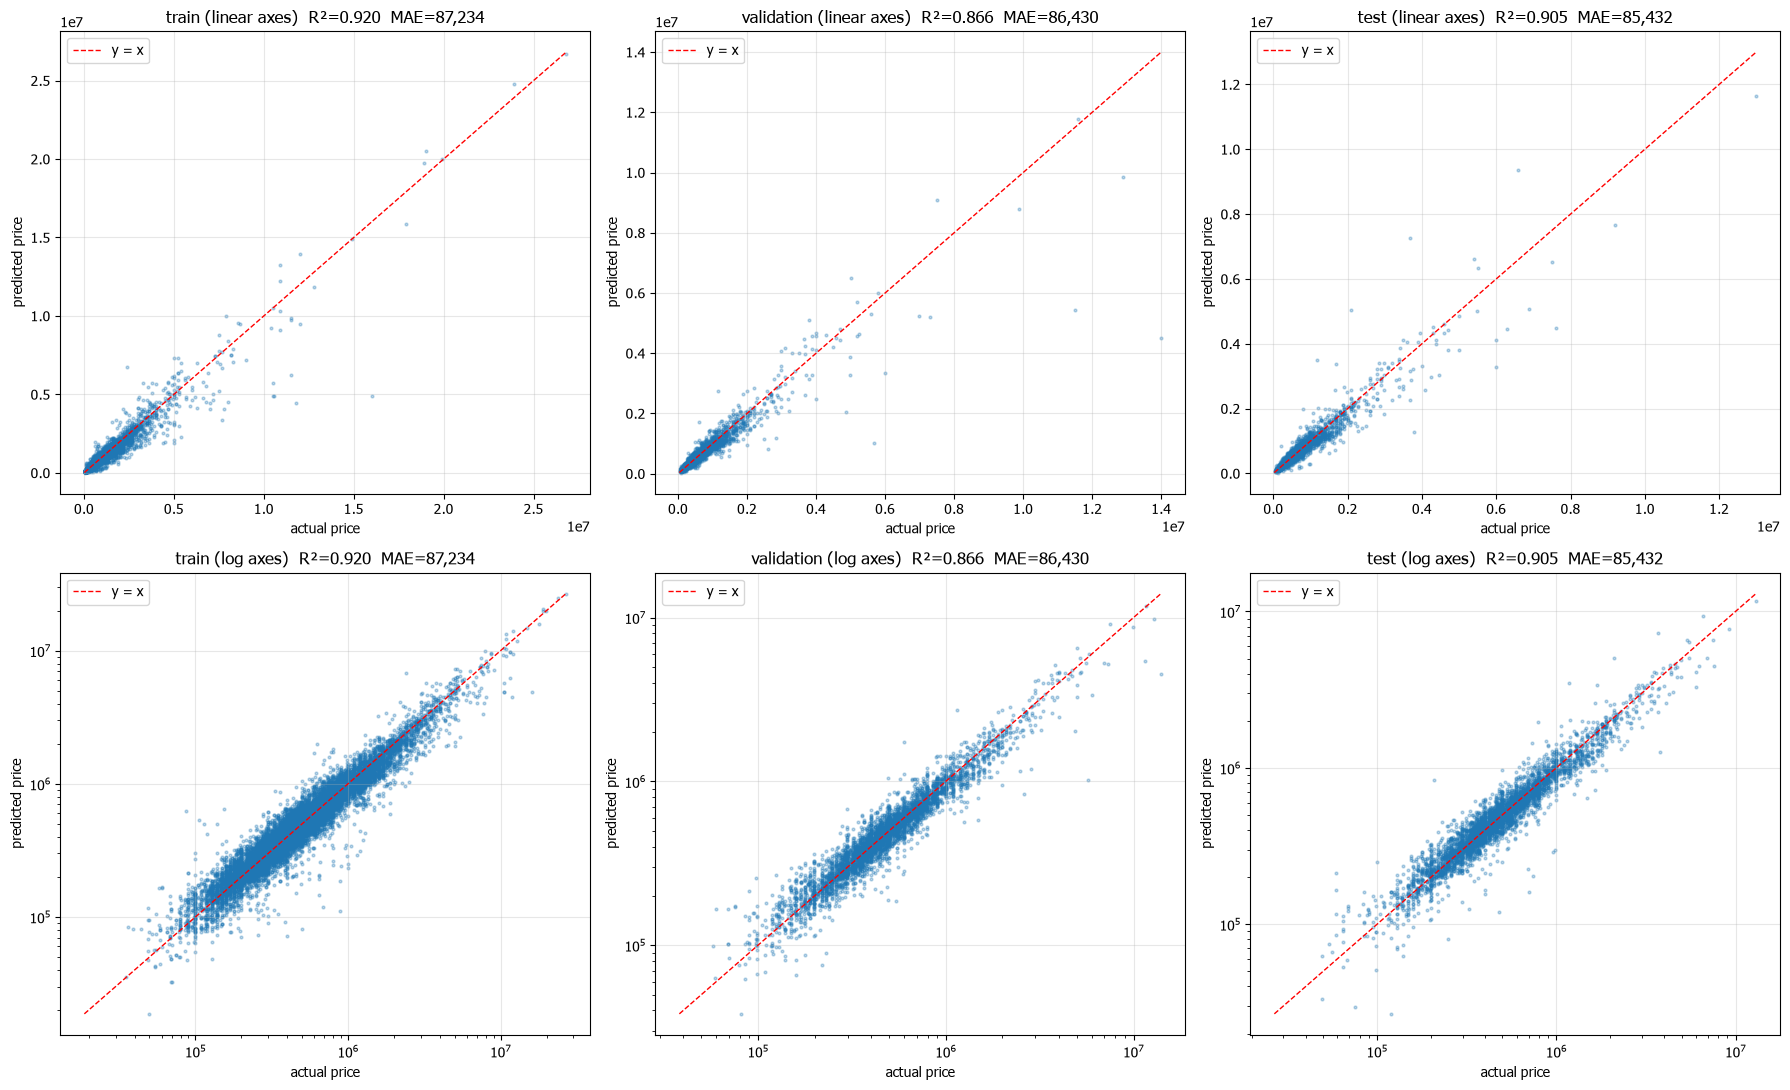

In [16]:
fig, ax = plt.subplots(2, 3, figsize=(18, 11))
for j, (nm, d, X) in enumerate([("train", train_n.loc[final["keep"]], X_tr.loc[final["keep"]]), ("validation", val_n, X_va), ("test", test_n, X_te)]):
    y, p = d[C.TARGET].values, predict(final, X)
    for i, scale in enumerate(["linear", "log"]):
        a = ax[i, j]; a.scatter(y, p, s=4, alpha=.3)
        lo, hi = min(y.min(), p.min()), max(y.max(), p.max()); a.plot([lo, hi], [lo, hi], "r--", lw=1, label="y = x")
        a.set_xscale(scale); a.set_yscale(scale); a.grid(alpha=.3); a.legend(); a.set_xlabel("actual price"); a.set_ylabel("predicted price")
        a.set_title(f"{nm} ({scale} axes)  R²={r2_score(y, p):.3f}  MAE={mean_absolute_error(y, p):,.0f}")
plt.tight_layout(); plt.show()

## 12. Which car `model` group has the largest error? (final model, validation, price scale)

In [17]:
ev = val_n.assign(pred=predict(final, X_va))
ev["err"] = ev["pred"] - ev[C.TARGET]; ev["abs_err"] = ev["err"].abs()
by = ev.groupby("model").agg(n=("err", "size"), MAE=("abs_err", "mean"), bias=("err", "mean"), total_abs_err=("abs_err", "sum"), mean_price=(C.TARGET, "mean"))
by["share_of_total_err_%"] = 100 * by["total_abs_err"] / by["total_abs_err"].sum()
by["MAPE_%"] = 100 * (ev["abs_err"] / ev[C.TARGET]).groupby(ev["model"]).mean()
by.sort_values("total_abs_err", ascending=False).head(20).round(1)

,n,MAE,bias,total_abs_err,mean_price,share_of_total_err_%,MAPE_%
model,,,,,,,
RANGE ROVER,7,2860867.2,-1582479.3,20026070.2,5288000.0,5.2,72.9
D-MAX,202,67928.5,-3827.2,13721560.6,472707.9,3.6,15.4
HILUX REVO,174,78647.5,2970.5,13684670.0,487660.9,3.5,16.0
CIVIC,185,70848.3,-18090.6,13106942.4,547404.3,3.4,13.4
RANGER,114,107524.6,-18606.8,12257801.7,505490.4,3.2,21.0
ALPHARD,57,206790.4,-10689.2,11787051.8,1693701.8,3.0,15.0
CAYENNE,27,399131.3,-105606.1,10776544.6,3032666.7,2.8,13.8
CAMRY,138,73196.4,-7064.4,10101103.3,537405.1,2.6,15.6
FORTUNER,122,72576.0,-9566.1,8854276.6,786311.5,2.3,9.6
